In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('../../'))
from src.analysis.metrics import *
from src.modeling.feature_engineering import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR

##### **It is assumed that the time series are Non-stationary**

In [2]:
# Restaurant data with the ingredients to predict
daily_consumption_df = pd.read_csv('../../data/restaurant_daily_consumption.csv', index_col=0, parse_dates=True)
display(daily_consumption_df)

,Salt,Sugar,Clove,Paprika
Date,,,,
2019-01-01,153.557043,1573.765650,0.097426,2.455129
2019-01-02,101.122931,1036.382257,0.064158,1.616792
2019-01-03,119.849399,1228.304898,0.076040,1.916198
2019-01-04,97.377637,997.997729,0.061782,1.556911
2019-01-05,202.245861,2072.764515,0.128317,3.233584
...,...,...,...,...
2019-06-26,116.104106,1189.920370,0.073663,1.856317
2019-06-27,205.991155,2111.149043,0.130693,3.293465
2019-06-28,179.774099,1842.457347,0.114059,2.874297


##### Apply Log Transformation

In [3]:
# Apply log transformation to numerical features
df_log_transformed = daily_consumption_df.copy()
df_log_transformed = np.log1p(daily_consumption_df) # Apply log1p (log(x + 1))
#display(df_log_transformed)

# Check correlation
corr_matrix = df_log_transformed.corr()
display(corr_matrix)

,Salt,Sugar,Clove,Paprika
Salt,1.000000,0.999997,0.961587,0.995016
Sugar,0.999997,1.000000,0.960940,0.994756
Clove,0.961587,0.960940,1.000000,0.983050
Paprika,0.995016,0.994756,0.983050,1.000000


##### Apply Holdout Cross-Validation

In [4]:
# Determine the split index for training and testing data - Holdout cross-validation
train_size = int(len(df_log_transformed) * 0.82) 

# Split the data into training and testing sets
df_train = df_log_transformed[:train_size]
df_test = df_log_transformed[train_size:]

##### Find the best lag feature to use

In [5]:
# Fit the VAR model
model = VAR(df_train)

# Select the best lag feature
select_lag_feature = model.select_order(maxlags=10)
select_lag_feature.summary()

c:\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-35.31,-35.23*,4.614e-16,-35.28*
1,-35.35,-34.93,4.433e-16,-35.18
2,-35.51,-34.74,3.806e-16,-35.20
3,-35.59,-34.48,3.515e-16,-35.14
4,-35.81,-34.36,2.828e-16,-35.22
5,-35.89,-34.10,2.623e-16*,-35.16
6,-35.75,-33.63,3.028e-16,-34.89
7,-35.90*,-33.44,2.626e-16,-34.90
8,-35.74,-32.94,3.121e-16,-34.60
9,-35.67,-32.54,3.388e-16,-34.40


##### Fit the model

In [6]:
# Fitting the model with the chosen lag order
var_results = model.fit(7, ic='aic')
var_results.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 16, Sep, 2024
Time:                     19:05:43
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -33.4685
Nobs:                     141.000    HQIC:                  -34.9086
Log likelihood:           1846.28    FPE:                2.63983e-16
AIC:                     -35.8945    Det(Omega_mle):     1.24927e-16
--------------------------------------------------------------------
Results for equation Salt
                coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------
const            995.879710      1588.061291            0.627           0.531
L1.Salt         -424.039674       288.539546           -1.470           0.142
L1.Sugar         407.431698       277.133358            1.470           0

##### Obtain preditions

In [7]:
# Store predictions
predicted_df = pd.DataFrame(index=df_test.index, columns=df_test.columns)

# Use rolling forecast (recursive forecasting)
total_history = df_train.values.tolist()  # Initialize the history with the training data

for t in range(len(df_test)):
    # Convert history to a NumPy array before forecasting
    history_array = np.array(total_history)
    
    # Predict one step ahead
    prediction = var_results.forecast(y=history_array, steps=1)
    
    # Store the prediction
    predicted_df.iloc[t] = prediction[0]
    
    # Update history with the actual test value
    total_history.append(df_test.iloc[t].values)

# Convert all columns to numeric values
predicted_df = predicted_df.apply(pd.to_numeric, errors='coerce')

Salt RMSE: 77.27620324882953
Sugar RMSE: 792.4674560298948
Clove RMSE: 0.0496197496410113
Paprika RMSE: 1.2195395017962405


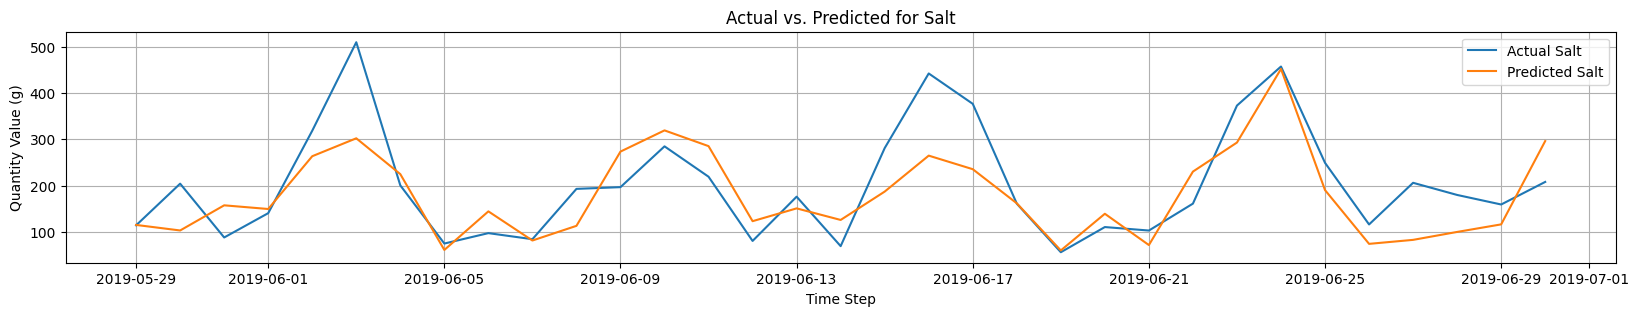

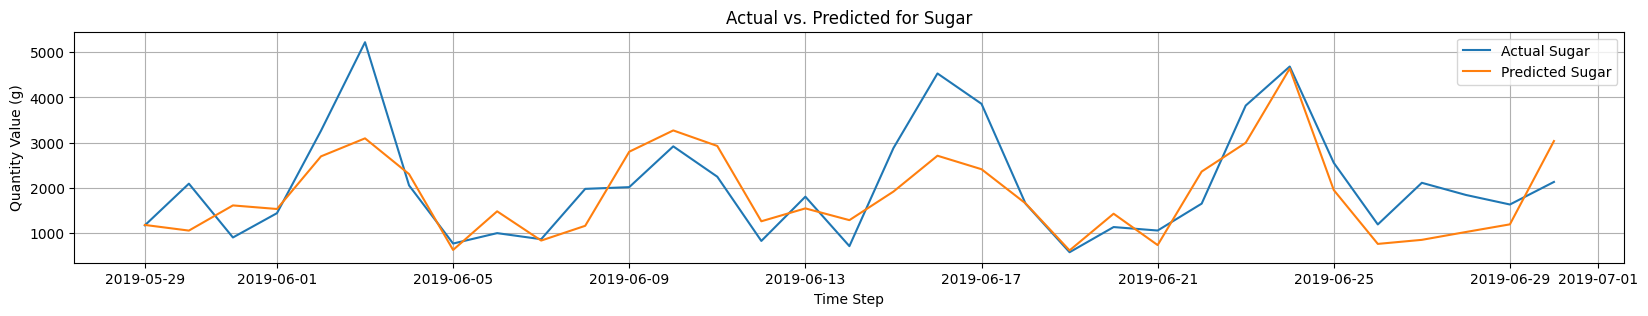

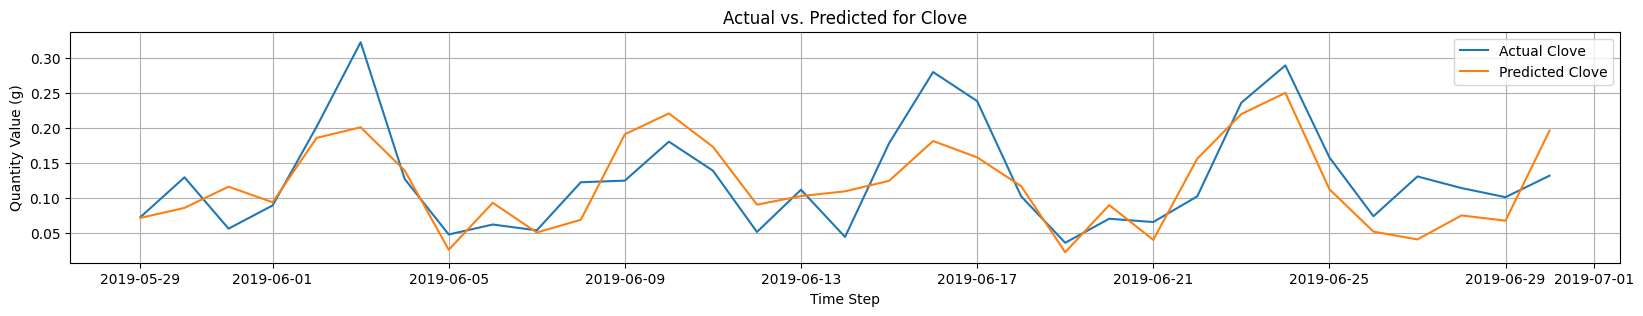

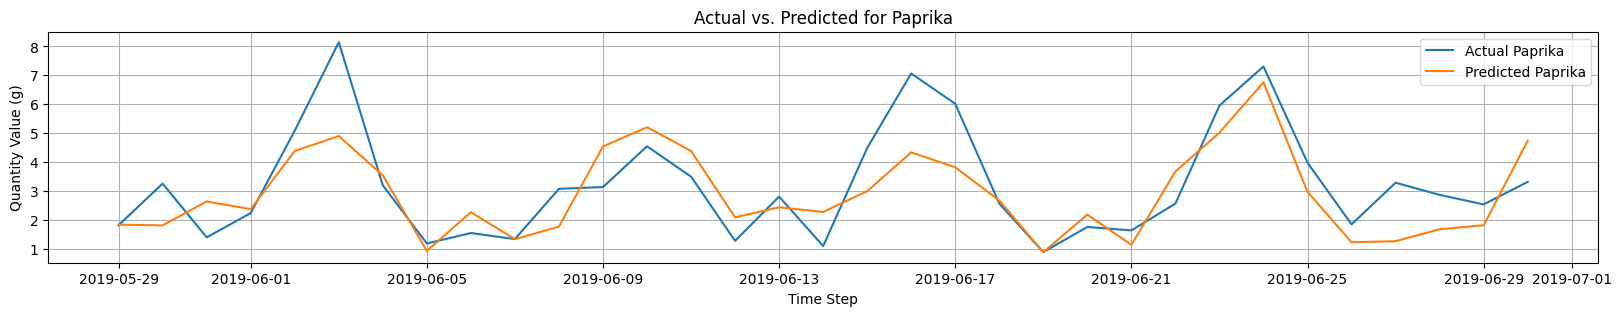

In [8]:
# Reverse the log transformation
df_test_actuals = np.expm1(df_test)
df_test_forecasts = np.expm1(predicted_df)

# Initialize a dictionary to store RMSE values
rmse_dict = {}

# Calculate RMSE for each ingredient
for col in df_test.columns:
    # Extract actual and predicted values
    actual = df_test_actuals[col]
    predicted = df_test_forecasts[col]
    
    # Calculate Root Mean Squared Error (RMSE)
    rmse = calculate_rmse(actual, predicted)
    
    # Store RMSE in the dictionary
    rmse_dict[col] = rmse

# Print RMSE for each ingredient
for ingredient, rmse in rmse_dict.items():
    print(f'{ingredient} RMSE: {rmse}')

# Plot predicted vs. actual values for each ingredient
for col in df_test.columns:
    plt.figure(figsize=(20, 3))
    
    # Plot actual values
    plt.plot(df_test_actuals.index, df_test_actuals[col], label=f'Actual {col}')
    
    # Plot predicted values
    plt.plot(df_test_forecasts.index, df_test_forecasts[col], label=f'Predicted {col}')
    
    # Add labels and title
    plt.title(f'Actual vs. Predicted for {col}')
    plt.xlabel('Time Step')
    plt.ylabel('Quantity Value (g)')
    
    plt.grid(True)
    plt.legend()
    plt.show()